# A latent-variable proximal method for unilateral contact in plane-strain elasticity

This notebook studies a two-dimensional cantilever beam under gravity. An unconstrained elastic solution is computed first; a frictionless unilateral constraint is then imposed on the lower boundary with the latent-variable proximal point (LVPP) method. The formulation follows the Signorini example of [Dokken, Farrell, Keith, Papadopoulos, and Surowiec](https://arxiv.org/abs/2503.05672).

In [1]:
from ngsolve import *
from ngsolve.webgui import Draw
from math import log as ln
from ngsolve.solvers import Newton

## Geometry

The reference beam and its relevant boundaries are

$$
\Omega=(0,1)\times(0,0.1),\qquad
\Gamma_D=\{0\}\times(0,0.1),\qquad
\Gamma_C=(0,1)\times\{0\}.
$$

The displacement is $u:\Omega\to\mathbb R^2$. The left edge $\Gamma_D$ is clamped; before contact is introduced, the remaining boundary carries natural zero-traction conditions. The mesh uses a target maximum element diameter of $0.03$.

In [2]:
#generate mesh of beam
from netgen.occ import *
shape = Rectangle(1,0.1).Face()
shape.edges.Max(X).name="right"
shape.edges.Min(X).name="left"
shape.edges.Max(Y).name="top"
shape.edges.Min(Y).name="bot"
mesh = Mesh(OCCGeometry(shape, dim=2).GenerateMesh(maxh=0.03))

In [3]:
Draw(mesh)

WebGLScene

In [4]:
print(mesh.GetBoundaries)

<bound method pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.GetBoundaries of <ngsolve.comp.Mesh object at 0x7efda240a990>>


## Plane-strain elasticity

Let

$$
V=\{v\in H^1(\Omega;\mathbb R^2):v=0\text{ on }\Gamma_D\}.
$$

With $\varepsilon(u)=\tfrac12(\nabla u+\nabla u^\top)$, the stress is

$$
\sigma(u)=2\mu\varepsilon(u)+\lambda\operatorname{tr}(\varepsilon(u))I,\qquad
\mu=\frac{E}{2(1+\nu)},\quad
\lambda=\frac{E\nu}{(1+\nu)(1-2\nu)}.
$$

The Lamé coefficient used here corresponds to **plane strain**, with $E=5\times10^7\,\mathrm{Pa}$ and $\nu=0.3$. Gravity gives the body force $f=(0,-\rho g_0)$, where $\rho=7850\,\mathrm{kg/m^3}$ and $g_0=9.81\,\mathrm{m/s^2}$. The displacement is approximated in a quadratic conforming space $V_h\subset V$.

In [5]:
#define finite element space (left boundary is fixed)
order = 2
fes = VectorH1(mesh, order=order, dirichlet="left")

In [6]:
#define bilinear form and right hand side to be gravity as volume force (E, nu are material parameters)
g = 9.81

#take density of steel for now and parameters such that we have significant deformation
width = 0.1
rho = 7850 #kg/m^3, converted to 2d density by formulation (cancels out with left hand side)
E, nu = 50e6, 0.3 #Pa, 1
mu  = E / 2 / (1+nu)
lam = E * nu / ((1+nu)*(1-2*nu))
def Stress(strain):
    return 2*mu*strain + lam*Trace(strain)*Id(2)

u,v = fes.TnT()
f = CoefficientFunction((0,-g))*rho
a = BilinearForm(InnerProduct(Stress(Sym(Grad(u))), Sym(Grad(v)))*dx)
lf = LinearForm(fes)
lf += f* v * dx

## Unconstrained reference problem

Define

$$
a(u,v)=\int_\Omega\sigma(u):\varepsilon(v)\,dx,\qquad
\ell(v)=\int_\Omega f\cdot v\,dx,\qquad
J(v)=\tfrac12a(v,v)-\ell(v).
$$

Without an obstacle, the equilibrium displacement is the minimizer of $J$ over $V$, equivalently

$$
a(u,v)=\ell(v)\qquad\forall v\in V.
$$

The following solve provides the unconstrained reference response under gravity; it does not enforce the lower bound introduced below.

In [7]:
#assemble forms
with TaskManager():
    a.Assemble()
    lf.Assemble()

In [8]:
#solve (directly for now) without constraints
gfu = GridFunction(fes)
with TaskManager():
    gfu.vec.data = a.mat.Inverse(freedofs=fes.FreeDofs()) *lf.vec

The deformed reference configuration shows the downward bending of the free end. It is an admissible contact configuration only where its bottom trace satisfies the obstacle bound.

In [9]:
#plot solution
Draw(gfu, mesh, deformation=True)

WebGLScene

In [10]:
# Introduce unilateral contact on the bottom boundary.
# The obstacle is defined in the next cell.

## Unilateral contact as a constrained minimization problem

On $\Gamma_C$, the vertical displacement is bounded from below by

$$
\phi(x)=
\begin{cases}
-M=-10, & x<0.75,\\
H=0.2, & x>0.75.
\end{cases}
$$

The right-hand branch is the intended rigid obstacle. Since $\phi=0.2$ bounds the displacement itself, the undeformed trace $u_y=0$ is already infeasible there. The bound $-M$ on the left retains a full-boundary formulation while placing an artificial obstacle far below the expected displacement; this is not identical to removing the constraint, although that branch should remain inactive. Only the vertical component is constrained, so the contact is frictionless.

Denote the normal gap by

$$
d(v)=v_y-\phi.
$$

Then

$$
K=\{v\in V:d(v)\geq0\text{ a.e. on }\Gamma_C\},\qquad
u=\operatorname*{arg\,min}_{v\in K}J(v).
$$

Equivalently, $u$ satisfies the variational inequality

$$
a(u,v-u)-\ell(v-u)\geq0\qquad\forall v\in K.
$$

In [11]:
# Artificial floor on the left.
# This must only be lower than all expected displacements.
M = 10.0
H = 0.2
# Small strictly positive initial gap
eps0 = H+1e-3
# Lower obstacle for the vertical displacement:
#
#     u_y >= phi
#
# phi = H   on x > 0.75
# phi = -M  on x < 0.75
phi = IfPos(x - 0.75, H, -M)

## Lagrangian and Signorini saddle point

Let $Q_+$ be the cone of nonnegative boundary multipliers. With $p\in Q_+$ interpreted as a positive upward contact reaction, the sign-consistent Lagrangian is

$$
\mathcal L(u,p)=J(u)-\langle p,u_y-\phi\rangle_{\Gamma_C},\qquad
\langle r,s\rangle_{\Gamma_C}=\int_{\Gamma_C}rs\,ds.
$$

Writing $I_K$ for the indicator of $K$, one has $J(v)+I_K(v)=\sup_{q\in Q_+}\mathcal L(v,q)$. Hence the primal problem has the saddle form

$$
\min_{v\in V}\max_{q\in Q_+}\mathcal L(v,q).
$$

Its optimality conditions are

$$
a(u,v)-\ell(v)-\langle p,v_y\rangle_{\Gamma_C}=0\qquad\forall v\in V,
$$

$$
d(u)\geq0,\qquad p\geq0,\qquad\langle p,d(u)\rangle_{\Gamma_C}=0.
$$

These are mechanical equilibrium, nonpenetration, nonnegative contact reaction, and complementarity.

## Entropic latent variable and discrete spaces

Let $d_0=1$ be the reference gap used by the notebook. For a positive gap, use $R(s)=s(\log(s/d_0)-1)$. Its derivative and inverse are

$$
R'(s)=\log(s/d_0)=\psi,\qquad (R')^{-1}(\psi)=d_0e^\psi=e^\psi.
$$

Thus the inequality is represented by the unconstrained latent field

$$
d(u)=e^\psi,\qquad u_y=\phi+e^\psi.
$$

Every finite $\psi$ gives a strictly positive reconstructed gap; exact contact is reached in the limit $\psi\to-\infty$. Let $W$ be a scalar latent space on $\Gamma_C$. The discretization couples a quadratic volume space $V_h\subset V$ to a quadratic boundary space $W_h\subset W$, with $X_h=V_h\times W_h$. Because $\phi$ jumps at $x=0.75$ while these traces are continuous, the coupling is understood in the weak boundary sense.

In [ ]:
#define space for the constraint
W = H1(
    mesh,
    order=order,
    definedon=mesh.Boundaries("bot"),
)

In [13]:
# Product space: displacement in the volume, latent variable on bot
X = fes * W

u, psi = X.TrialFunction()
v, w = X.TestFunction()


gfcontact = GridFunction(X)
uh, psih = gfcontact.components


# Latent variable from the previous OUTER LVPP iteration
psi_old = GridFunction(W)

## Latent-field initialization

Here $\varepsilon_0=H+10^{-3}=0.201$ and

$$
\psi^0(x)=
\begin{cases}
\log(M+\varepsilon_0), & x<0.75,\\
\log(\varepsilon_0), & x>0.75.
\end{cases}
$$

Hence the initial latent gap and its bound-preserving displacement reconstruction are

$$
e^{\psi^0}=
\begin{cases}
M+\varepsilon_0, & x<0.75,\\
\varepsilon_0, & x>0.75,
\end{cases}
\qquad
\phi+e^{\psi^0}=
\begin{cases}
0.201, & x<0.75,\\
0.401, & x>0.75.
\end{cases}
$$

Both latent gaps are strictly positive. Thus the latent reconstruction is strictly feasible, independently of the initial primal displacement.

In [14]:
# Choose a strictly feasible initial latent gap.
# Its two branches are documented in the preceding Markdown cell.
psi0 = IfPos(
    x - 0.75,
    ln(eps0),
    ln(M + eps0),
)

psi_old.Set(
    psi0,
    definedon=mesh.Boundaries("bot"),
)

# Initial guess for the first Newton solve
psih.vec.data = psi_old.vec


# Proximal parameter as a mutable CoefficientFunction
alpha = Parameter(5e-4)

## Bregman proximal minimization and LVPP saddle problem

For $s,t>0$, the entropy generates the Bregman divergence

$$
D_R(s,t)=s\log\!\left(\frac{s}{t}\right)-s+t.
$$

With $d^{k-1}=e^{\psi^{k-1}}$, one LVPP step stems from the Bregman proximal problem

$$
u^k\in\operatorname*{arg\,min}_{u\in K}
\left[J(u)+\frac{1}{\alpha_k}\int_{\Gamma_C}
D_R\bigl(d(u),d^{k-1}\bigr)\,ds\right].
$$

Using $R(s)=\max_{\eta\in\mathbb R}(\eta s-e^\eta)$ gives the equivalent convex--concave formulation, up to an additive constant,

$$
\min_{u\in V}\max_{\psi\in W}\mathcal S_k(u,\psi),
$$

$$
\mathcal S_k(u,\psi)=\alpha_kJ(u)
+\langle\psi-\psi^{k-1},u_y-\phi\rangle_{\Gamma_C}
-\langle e^\psi,1\rangle_{\Gamma_C}.
$$

Restricting this saddle problem to $V_h\times W_h$ gives the mixed equations assembled below:

$$
\alpha_k\bigl(a(u_h^k,v_h)-\ell(v_h)\bigr)
+\langle\psi_h^k-\psi_h^{k-1},(v_h)_y\rangle_{\Gamma_C}=0
\qquad\forall v_h\in V_h,
$$

$$
\langle (u_h^k)_y-\phi-e^{\psi_h^k},w_h\rangle_{\Gamma_C}=0
\qquad\forall w_h\in W_h.
$$

The previous latent field $\psi_h^{k-1}$ is fixed during this subproblem. Writing

$$
p_h^k=\frac{\psi_h^{k-1}-\psi_h^k}{\alpha_k}
$$

reduces the first equation to $a(u_h^k,v_h)-\ell(v_h)-\langle p_h^k,(v_h)_y\rangle_{\Gamma_C}=0$, with the same sign convention as the contact Lagrangian.

In [15]:
F = BilinearForm(X)

# Mechanical equilibrium:
#
# alpha * (a(u,v) - l(v))
F += alpha * (
    InnerProduct(
        Stress(Sym(Grad(u))),
        Sym(Grad(v)),
    )
    - f * v
) * dx


# Proximal contact force:
#
# <psi - psi_old, v_y>_bot
F += (
    psi - psi_old
) * v[1] * ds("bot")


# Latent gap relation:
#
# u_y - phi = exp(psi)
F += (
    u[1]
    - phi
    - exp(psi)
) * w * ds("bot")

## Inner Newton solves and outer proximal iteration

For each outer index $k$, the smooth mixed subproblem is solved with $\psi^{k-1}$ and $\alpha_k$ fixed. The converged pair initializes the next subproblem. The outer iteration starts from $\alpha_0=5\times10^{-5}$; this value is doubled after each step and capped at $10$. Each subproblem permits at most $20$ Newton steps with tolerance $10^{-9}$, and the outer loop permits at most $20$ steps. It stops, after at least three iterates, when

$$
\lVert u^k-u^{k-1}\rVert_{L^2(\Omega)}<10^{-8}.
$$

In [16]:
u_old = GridFunction(fes)
pressure = GridFunction(W)

alpha_k = 5e-5

with TaskManager():
    for k in range(20):

        # Store u^{k-1} for the outer stopping criterion
        u_old.vec.data = uh.vec

        alpha.Set(alpha_k)

        # Solve the current smooth LVPP subproblem
        Newton(
            F,
            gfcontact,
            inverse="umfpack",
            maxit=20,
            maxerr=1e-9,
            printing=False,
        )

        # Contact pressure:
        #
        # p^k = (psi^{k-1} - psi^k) / alpha_k
        #
        # This must be computed before psi_old is overwritten.
        pressure.vec.data = psi_old.vec
        pressure.vec.data -= psih.vec
        pressure.vec.data *= 1.0 / alpha_k

        # L2 change of the displacement between outer iterations
        du = sqrt(
            Integrate(
                InnerProduct(
                    uh - u_old,
                    uh - u_old,
                ),
                mesh,
            )
        )

        print(
            f"{k:2d}: "
            f"alpha = {alpha_k:8.3e}, "
            f"||u^k-u^(k-1)||_L2 = {du:8.3e}"
        )

        if k >= 2 and du < 1e-8:
            break

        # Advance the OUTER latent variable
        psi_old.vec.data = psih.vec

        # Conservative growth of the proximal parameter
        alpha_k = min(2.0 * alpha_k, 10.0)

 0: alpha = 5.000e-05, ||u^k-u^(k-1)||_L2 = 4.644e-02
 1: alpha = 1.000e-04, ||u^k-u^(k-1)||_L2 = 1.056e-03
 2: alpha = 2.000e-04, ||u^k-u^(k-1)||_L2 = 4.745e-05
 3: alpha = 4.000e-04, ||u^k-u^(k-1)||_L2 = 9.007e-07
 4: alpha = 8.000e-04, ||u^k-u^(k-1)||_L2 = 8.594e-09


## Bound-preserving reconstruction

The discrete mixed problem produces both the primal trace $u_{h,y}$ and the latent reconstruction

$$
d_h^{\mathrm{lat}}=e^{\psi_h}>0,\qquad
u_{h,y}^{\mathrm{lat}}=\phi+e^{\psi_h}>\phi.
$$

The latter satisfies the lower bound by construction. Since the coupling equation is imposed weakly in $W_h$, $u_{h,y}$ and $u_{h,y}^{\mathrm{lat}}$ need not agree pointwise. In the Signorini limit, active contact is characterized by a vanishing gap and a positive multiplier, whereas separation has a positive gap and zero multiplier.

In [17]:
# Latent gap:
#
#     gap = u_y - phi = exp(psi)
latent_gap = exp(psih)

# Bound-preserving vertical displacement
latent_uy = phi + latent_gap


Draw(
    gfu,
    mesh,
    "without_contact",
    deformation=True,
)

Draw(
    uh,
    mesh,
    "with_contact",
    deformation=True,
)


WebGLScene

## Boundary multiplier

The final graph shows the discrete contact multiplier $p_h$ along $\Gamma_C$. The dashed line at $x=0.75$ marks the jump in the obstacle; the curve is a finite-element, finite-LVPP-iteration approximation rather than an analytical pressure distribution.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Avoid the corner points, because they belong to several boundaries
xs = np.linspace(1e-8, 1.0 - 1e-8, 600)

pvals = []

for xi in xs:
    mp = mesh(float(xi), 0.0, 0.0, BND)

    if mp.nr == -1:
        pvals.append(np.nan)
    else:
        pvals.append(float(pressure(mp)))

pvals = np.asarray(pvals)

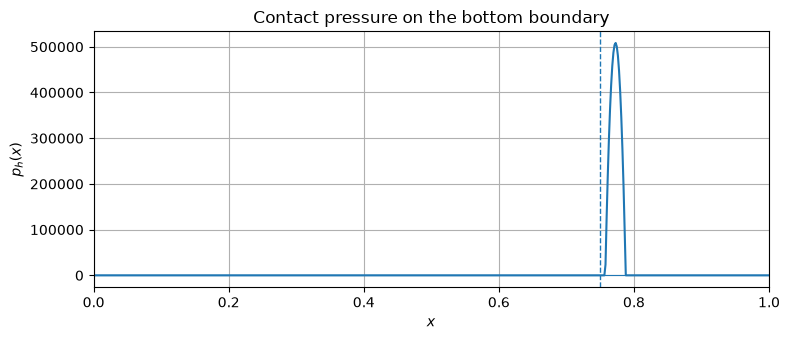

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(xs, pvals, linewidth=1.5)
ax.axhline(0.0, linewidth=0.8)
ax.axvline(0.75, linestyle="--", linewidth=1.0)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$p_h(x)$")
ax.set_title("Contact pressure on the bottom boundary")
ax.grid(True)
ax.set_xlim(0.0, 1.0)

fig.tight_layout()
plt.show()